# Script version: 2025-05-06
# Author: Felicity Simpson
# Description: Preprocessing

This notebook documents the construction of subject-level functional connectivity matrices used as input to the PLS analysis. It includes Fisher r-to-z transformation and vectorisation of the upper triangle. Raw neuroimaging data are not included.

In [8]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_mat_timeseries(folder_path, variable_name='data'):
    timeseries_dict = {}
    for fname in os.listdir(folder_path):
        if fname.endswith(".mat"):
            sub_id    = fname.replace(".mat", "")
            full_path = os.path.join(folder_path, fname)
            try:
                with h5py.File(full_path, 'r') as f:
                    if variable_name not in f:
                        print(f"Warning: {fname} does not contain variable '{variable_name}'")
                        continue
                    ts = np.array(f[variable_name]).T
                    timeseries_dict[sub_id] = ts
            except Exception as e:
                print(f"Error loading {fname}: {e}")
    return timeseries_dict

def compute_connectivity(timeseries_dict):
    conn_matrices = {}
    for sub_id, ts in timeseries_dict.items():
        corr_matrix = np.corrcoef(ts, rowvar=False)
        conn_matrices[sub_id] = corr_matrix
    return conn_matrices

def fisher_r_to_z(conn_matrices):
    z_matrices = {}
    for sub_id, r in conn_matrices.items():
        # 1) zero the diagonal before transform
        np.fill_diagonal(r, 0.0)
        # 2) clip to avoid infinities
        r_clipped = np.clip(r, -0.9999, 0.9999)
        # 3) Fisher r→z
        z = np.arctanh(r_clipped)
        z_matrices[sub_id] = z
    return z_matrices

# ── Example usage ──
folder = r"C:\Users\c3371138\projects\data\x_preped"
timeseries_dict = load_mat_timeseries(folder, variable_name='data')
print(f"Loaded {len(timeseries_dict)} participants’ timeseries")

conn_matrices = compute_connectivity(timeseries_dict)
print(f"Computed connectivity matrices for {len(conn_matrices)} participants")

z_matrices = fisher_r_to_z(conn_matrices)
print(f"Converted to Fisher‐z matrices for {len(z_matrices)} participants")


Loaded 186 participants’ timeseries
Computed connectivity matrices for 186 participants
Converted to Fisher‐z matrices for 186 participants


data_sub-2001 correlation matrix shape: (400, 400)


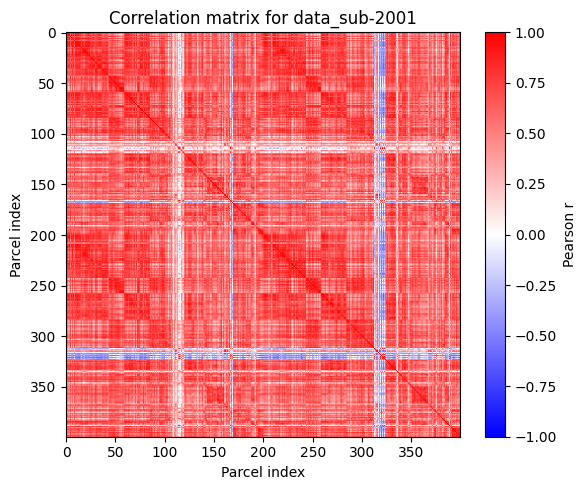

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def compute_connectivity(timeseries_dict):
    """
    Compute full correlation (Pearson r) matrices for each subject.

    Args:
        timeseries_dict (dict): Keys = subject IDs, Values = (T x N) time series arrays

    Returns:
        dict: Keys = subject IDs, Values = (N x N) correlation matrices.
    """
    conn_matrices = {}
    for sub_id, ts in timeseries_dict.items():
        # Best practice: Check shape and handle exceptions
        if ts.ndim != 2:
            print(f"Warning: Time series for {sub_id} is not 2D (shape={ts.shape}), skipping.")
            continue
        # rowvar=False means columns (parcels) are variables
        corr_matrix = np.corrcoef(ts, rowvar=False)
        conn_matrices[sub_id] = corr_matrix
    return conn_matrices

# --- Run it and check result ---
corrs = compute_connectivity(timeseries_dict)

# Best practice: sanity check a result
sub_id = next(iter(corrs))
print(f"{sub_id} correlation matrix shape: {corrs[sub_id].shape}")

plt.figure(figsize=(6, 5))
plt.imshow(corrs[sub_id], aspect='auto', cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(label='Pearson r')
plt.title(f'Correlation matrix for {sub_id}')
plt.xlabel('Parcel index')
plt.ylabel('Parcel index')
plt.tight_layout()
plt.show()


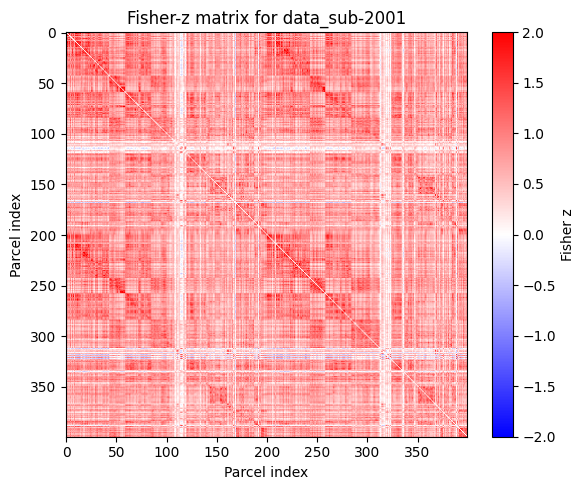

In [10]:
def fisher_r_to_z(conn_matrices):
    """
    Fisher r-to-z transform for each correlation matrix.

    Args:
        conn_matrices (dict): 
            Keys   = subject IDs,
            Values = (N × N) Pearson-r correlation matrices.

    Returns:
        dict: 
            Keys   = subject IDs,
            Values = Fisher-z transformed matrices.
    """
    z_matrices = {}
    for sub_id, r in conn_matrices.items():
        # 1) Clip to avoid infinities at r = ±1
        r_clipped = np.clip(r, -0.9999, 0.9999)
        # 2) Apply Fisher transform
        z = np.arctanh(r_clipped)
        # 3) (Optional) zero the diagonal
        np.fill_diagonal(z, 0.0)
        z_matrices[sub_id] = z
    return z_matrices

# --- Run the transform ---
zs = fisher_r_to_z(corrs)

# --- Quick visual sanity check for the same sub_id used earlier ---
plt.figure(figsize=(6,5))
plt.imshow(zs[sub_id], aspect='auto', cmap='bwr', vmin=-2, vmax=2)
plt.colorbar(label='Fisher z')
plt.title(f'Fisher-z matrix for {sub_id}')
plt.xlabel('Parcel index')
plt.ylabel('Parcel index')
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
print("min/max:", np.min(zs[sub_id]), np.max(zs[sub_id]))


min/max: -0.810227786100729 2.359633881628117


## Why Normalise Resting-State Connectivity Vectors?

Normalising each subject’s connectivity vector (e.g., via z-scoring) is sometimes used to:

- **Reduce variance in mean connectivity across participants**  
  (e.g., due to motion, scanner drift, or global signal differences)

- **Ensure that subsequent analyses (e.g., PLS) focus on relative patterns of connectivity**  
  rather than absolute differences in overall connectivity strength

However, normalisation is not always recommended, as it can:

- **Distort the true distribution of connection strengths**

- **Remove meaningful individual differences in global connectivity**


In [12]:
# %% 
# Define upper triangle indices just once
n_parcels = next(iter(zs.values())).shape[0]
upper_tri_indices = np.triu_indices(n_parcels, k=1)

# %% 
import pandas as pd
# import os
# save_dir = r'C:\Users\c3371138\projects\data\cleaned_matrices'
# os.makedirs(save_dir, exist_ok=True)

# --- Flatten each subject's z-vector (no thresholding) ---
all_flat = []
subject_ids = []
for sub_id, zmat in zs.items():
    flat = zmat[upper_tri_indices]
    all_flat.append(flat)
    subject_ids.append(sub_id)

# Combine all subjects into a single DataFrame
df_flat = pd.DataFrame(all_flat, index=subject_ids)

# # Optionally save to CSV (commented out for now)
# df_flat.to_csv(os.path.join(save_dir, "all_subjects_flattened.csv"))
# print(f"Saved group matrix to {os.path.join(save_dir, 'all_subjects_flattened.csv')}")

# Now `df_flat` holds your flattened Fisher-z connectivity for all subjects


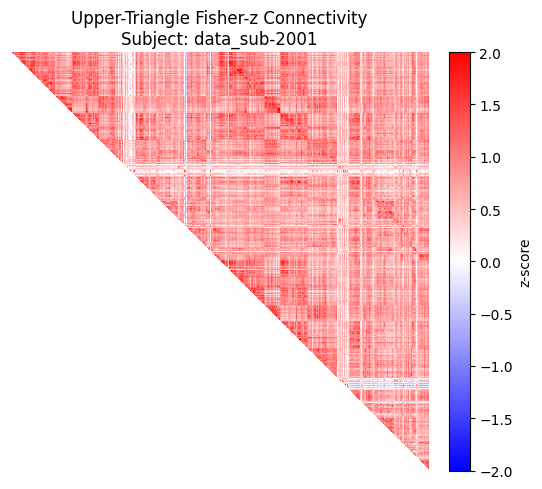

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a subject (e.g. the first one)
sub_id = next(iter(zs))
zmat   = zs[sub_id].copy()

# Zero out lower triangle *and* diagonal
tril_i, tril_j = np.tril_indices_from(zmat, k=0)
zmat[tril_i, tril_j] = 0.0

# Plot only the upper triangle
plt.figure(figsize=(6, 5))
im = plt.imshow(zmat, vmin=-2, vmax=2, cmap='bwr')
plt.title(f'Upper-Triangle Fisher-z Connectivity\nSubject: {sub_id}')
plt.axis('off')
plt.colorbar(im, fraction=0.046, pad=0.04, label='z-score')
plt.tight_layout()
plt.show()


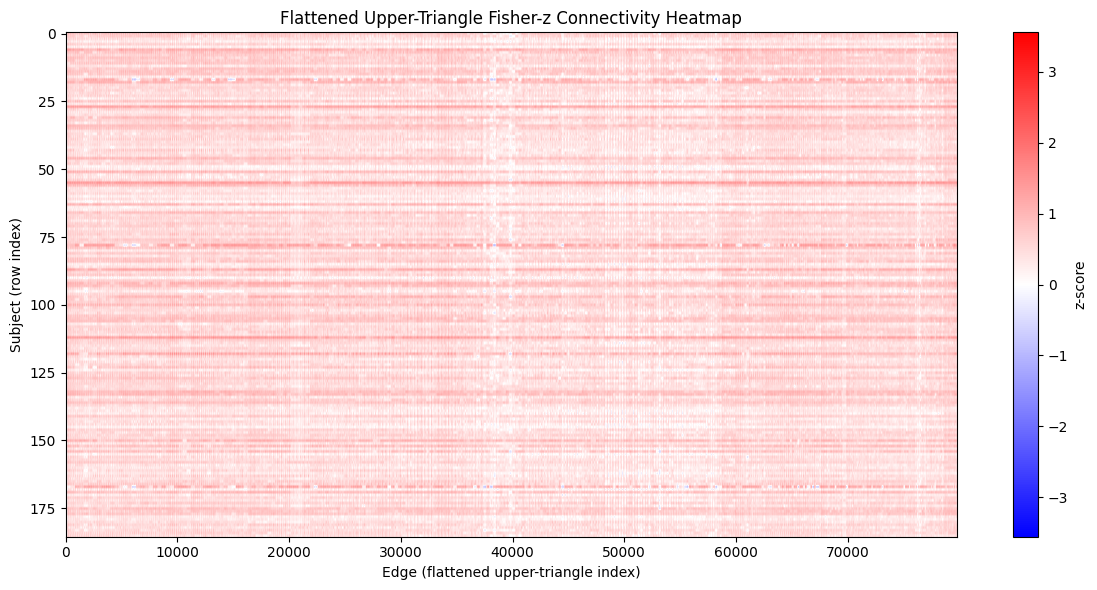

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1) Rebuild df_flat from zs (your Fisher-z dict)
n_parcels = next(iter(zs.values())).shape[0]
tri_i, tri_j = np.triu_indices(n_parcels, k=1)

all_flat = []
subject_ids = []
for sub_id, zmat in zs.items():
    flat = zmat[tri_i, tri_j]
    all_flat.append(flat)
    subject_ids.append(sub_id)

df_flat = pd.DataFrame(all_flat, index=subject_ids)

# 2) Determine symmetric color limits
abs_max = np.abs(df_flat.values).max()

# 3) Plot with red=positive, blue=negative
plt.figure(figsize=(12, 6))
im = plt.imshow(
    df_flat.values,
    aspect='auto',
    cmap='bwr',
    vmin=-abs_max,
    vmax=+abs_max
)
plt.xlabel('Edge (flattened upper-triangle index)')
plt.ylabel('Subject (row index)')
plt.title('Flattened Upper-Triangle Fisher-z Connectivity Heatmap')
plt.colorbar(im, label='z-score')
plt.tight_layout()
plt.show()


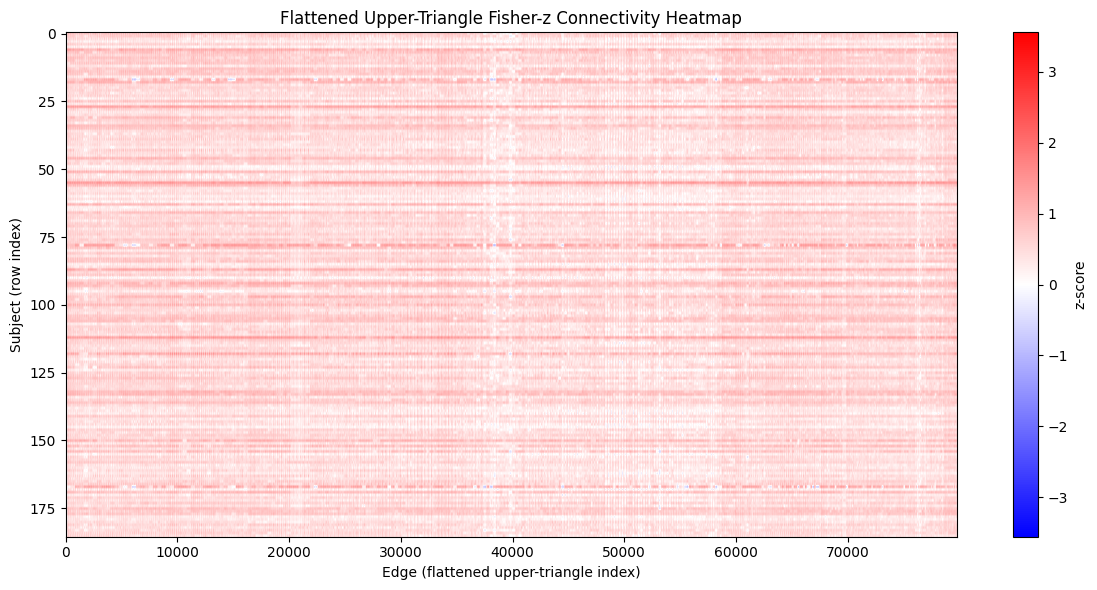

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1) Rebuild df_flat from zs (your Fisher-z dict)
n_parcels = next(iter(zs.values())).shape[0]
tri_i, tri_j = np.triu_indices(n_parcels, k=1)

all_flat = []
subject_ids = []
for sub_id, zmat in zs.items():
    flat = zmat[tri_i, tri_j]
    all_flat.append(flat)
    subject_ids.append(sub_id)

df_flat = pd.DataFrame(all_flat, index=subject_ids)

# 2) Determine symmetric color limits
abs_max = np.abs(df_flat.values).max()

# 3) Plot with red=positive, blue=negative
plt.figure(figsize=(12, 6))
im = plt.imshow(
    df_flat.values,
    aspect='auto',
    cmap='bwr',
    vmin=-abs_max,
    vmax=+abs_max
)
plt.xlabel('Edge (flattened upper-triangle index)')
plt.ylabel('Subject (row index)')
plt.title('Flattened Upper-Triangle Fisher-z Connectivity Heatmap')
plt.colorbar(im, label='z-score')
plt.tight_layout()
plt.show()
